In [2]:
# 🩺 MedAgent: AI-Powered Clinical Decision Support System

## Notebook 01: Data Exploration

### Project Description

MedAgent is an AI-powered clinical decision support system that analyzes chest X-ray images using deep learning and Vision-Language Models (VLMs). The project combines Computer Vision, Retrieval-Augmented Generation (RAG), and Agentic AI to assist clinicians in disease detection and report generation.

This notebook performs the initial exploration of the NIH Chest X-ray14 dataset. Before training any machine learning model, we need to understand the dataset structure, metadata, disease distribution, image quality, and potential data issues.

---

## Objectives

- Verify dataset structure
- Load metadata
- Understand dataset dimensions
- Explore patient demographics
- Analyze disease distribution
- Validate image files
- Identify missing values
- Generate exploratory visualizations
- Prepare for preprocessing

---

## Dataset

NIH Chest X-ray14 Dataset

Contents:

- Chest X-ray Images
- Metadata CSV
- Bounding Box CSV
- Train/Test Split Files

---

SyntaxError: invalid syntax (109889664.py, line 7)

In [1]:
from pathlib import Path
import random
import warnings
import logging
import numpy as np
import pandas as pd
import cv2
from PIL import Image


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [3]:
# ==========================================
# Project Configuration
# ==========================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

IMAGE_DIR = RAW_DATA_DIR / "images"

METADATA_FILE = RAW_DATA_DIR / "Data_Entry_2017.csv"
BBOX_FILE = RAW_DATA_DIR / "BBox_List_2017.csv"

TRAIN_LIST = RAW_DATA_DIR / "train_val_list.txt"
TEST_LIST = RAW_DATA_DIR / "test_list.txt"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
PLOTS_DIR = OUTPUT_DIR / "plots"
REPORTS_DIR = OUTPUT_DIR / "reports"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Metadata     :", METADATA_FILE)
print("Images       :", IMAGE_DIR)

Project Root : c:\Users\HP\MED-AGENT
Metadata     : c:\Users\HP\MED-AGENT\data\raw\Data_Entry_2017.csv
Images       : c:\Users\HP\MED-AGENT\data\raw\images


In [4]:
# ==========================================
# Logging Configuration
# ==========================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger("MedAgent")

logger.info("Logging initialized successfully.")

2026-07-18 23:08:10,408 | INFO | Logging initialized successfully.


In [5]:
# ==========================================
# Verify Dataset Structure
# ==========================================

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

items = {
    "Metadata CSV": METADATA_FILE,
    "Bounding Box CSV": BBOX_FILE,
    "Train List": TRAIN_LIST,
    "Test List": TEST_LIST,
    "Images Folder": IMAGE_DIR
}

for name, path in items.items():
    if path.exists():
        print(f"✅ {name:<20} Found")
    else:
        print(f"❌ {name:<20} Missing")

DATASET VERIFICATION
✅ Metadata CSV         Found
✅ Bounding Box CSV     Found
✅ Train List           Found
✅ Test List            Found
✅ Images Folder        Found


In [11]:
# ==========================================
# Count Images in Dataset
# ==========================================

image_folders = sorted(IMAGE_DIR.glob("images_*"))

total_images = 0

print(f"Number of image folders: {len(image_folders)}\n")

for folder in image_folders:

    actual_image_folder = folder / "images"

    image_count = len(list(actual_image_folder.glob("*.png")))

    total_images += image_count

    print(f"{folder.name:<15} {image_count} images")

print("\n" + "=" * 50)
print(f"Total Images: {total_images}")

Number of image folders: 12

images_001      4999 images
images_002      10000 images
images_003      10000 images
images_004      10000 images
images_005      10000 images
images_006      10000 images
images_007      10000 images
images_008      10000 images
images_009      10000 images
images_010      10000 images
images_011      10000 images
images_012      7121 images

Total Images: 112120


In [12]:
print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print(f"Project Root       : {PROJECT_ROOT}")
print(f"Metadata File      : {METADATA_FILE.name}")
print(f"Bounding Boxes     : {BBOX_FILE.name}")
print(f"Image Directories  : {len(image_folders)}")
print(f"Output Directory   : {OUTPUT_DIR}")

print("\n✅ Dataset verification completed successfully.")

PROJECT SUMMARY
Project Root       : c:\Users\HP\MED-AGENT
Metadata File      : Data_Entry_2017.csv
Bounding Boxes     : BBox_List_2017.csv
Image Directories  : 12
Output Directory   : c:\Users\HP\MED-AGENT\outputs\eda

✅ Dataset verification completed successfully.


In [13]:
    # ==========================================
# Load Metadata
# ==========================================

logger.info("Loading metadata...")

df = pd.read_csv(METADATA_FILE)

logger.info("Metadata loaded successfully.")

print(f"Dataset Shape: {df.shape}")


2026-07-18 23:14:34,677 | INFO | Loading metadata...
2026-07-18 23:14:34,881 | INFO | Metadata loaded successfully.


Dataset Shape: (112120, 11)


In [14]:
# ==========================================
# Preview Dataset
# ==========================================

display(df.head())

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


In [15]:
# ==========================================
# Dataset Information
# ==========================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  str    
 1   Finding Labels               112120 non-null  str    
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Sex                  112120 non-null  str    
 6   View Position                112120 non-null  str    
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), str(4)
memory usage: 9.4 MB


In [16]:

# ==========================================
# Column Names
# ==========================================

print("Columns in Dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in Dataset:

1. Image Index
2. Finding Labels
3. Follow-up #
4. Patient ID
5. Patient Age
6. Patient Sex
7. View Position
8. OriginalImage[Width
9. Height]
10. OriginalImagePixelSpacing[x
11. y]


In [17]:
# ==========================================
# Missing Values
# ==========================================

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Percentage": (missing.values / len(df) * 100).round(2)
})

display(missing_df)

,Column,Missing Values,Percentage
0,Image Index,0,0.0
1,Finding Labels,0,0.0
2,Follow-up #,0,0.0
3,Patient ID,0,0.0
4,Patient Age,0,0.0
5,Patient Sex,0,0.0
6,View Position,0,0.0
7,OriginalImage[Width,0,0.0
8,Height],0,0.0
9,OriginalImagePixelSpacing[x,0,0.0


In [18]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [19]:
# ==========================================
# Statistical Summary
# ==========================================

display(df.describe(include="all"))

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120,112120,112120.000000,112120.000000,112120.000000,112120,112120,112120.000000,112120.000000,112120.000000,112120.000000
unique,112120,836,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN
top,00000001_000.png,No Finding,NaN,NaN,NaN,M,PA,NaN,NaN,NaN,NaN
freq,1,60361,NaN,NaN,NaN,63340,67310,NaN,NaN,NaN,NaN
mean,NaN,NaN,8.573751,14346.381743,46.626365,NaN,NaN,2646.078844,2486.438842,0.155649,0.155649
std,NaN,NaN,15.406320,8403.876972,16.602680,NaN,NaN,341.246429,401.268227,0.016174,0.016174
min,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,1143.000000,966.000000,0.115000,0.115000
25%,NaN,NaN,0.000000,7310.750000,34.000000,NaN,NaN,2500.000000,2048.000000,0.143000,0.143000
50%,NaN,NaN,3.000000,13993.000000,49.000000,NaN,NaN,2518.000000,2544.000000,0.143000,0.143000
75%,NaN,NaN,10.000000,20673.000000,59.000000,NaN,NaN,2992.000000,2991.000000,0.168000,0.168000


In [21]:
# ==========================================
# Dataset Summary
# ==========================================

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Total Images           : {len(df):,}")
print(f"Total Columns          : {df.shape[1]}")
print(f"Unique Patients        : {df['Patient ID'].nunique():,}")
print(f"Unique Diseases Labels : {df['Finding Labels'].nunique():,}")
print(f"Male Patients          : {(df['Patient Sex']=='M').sum():,}")
print(f"Female Patients        : {(df['Patient Sex']=='F').sum():,}")

DATASET SUMMARY
Total Images           : 112,120
Total Columns          : 11
Unique Patients        : 30,805
Unique Diseases Labels : 836
Male Patients          : 63,340
Female Patients        : 48,780


In [22]:
# ==========================================
# Disease Labels
# ==========================================

print("=" * 60)
print("UNIQUE DISEASE LABELS")
print("=" * 60)

unique_labels = sorted(df["Finding Labels"].unique())

print(f"Total Unique Label Combinations: {len(unique_labels)}\n")

for label in unique_labels[:20]:
    print(label)

print("\n...")

UNIQUE DISEASE LABELS
Total Unique Label Combinations: 836

Atelectasis
Atelectasis|Cardiomegaly
Atelectasis|Cardiomegaly|Consolidation
Atelectasis|Cardiomegaly|Consolidation|Edema
Atelectasis|Cardiomegaly|Consolidation|Edema|Effusion|Infiltration
Atelectasis|Cardiomegaly|Consolidation|Edema|Effusion|Infiltration|Mass
Atelectasis|Cardiomegaly|Consolidation|Edema|Effusion|Infiltration|Mass|Nodule
Atelectasis|Cardiomegaly|Consolidation|Edema|Effusion|Mass
Atelectasis|Cardiomegaly|Consolidation|Edema|Effusion|Pleural_Thickening
Atelectasis|Cardiomegaly|Consolidation|Effusion
Atelectasis|Cardiomegaly|Consolidation|Effusion|Infiltration
Atelectasis|Cardiomegaly|Consolidation|Effusion|Infiltration|Mass
Atelectasis|Cardiomegaly|Consolidation|Effusion|Infiltration|Mass|Pleural_Thickening
Atelectasis|Cardiomegaly|Consolidation|Effusion|Infiltration|Nodule|Pleural_Thickening
Atelectasis|Cardiomegaly|Consolidation|Effusion|Infiltration|Pneumonia
Atelectasis|Cardiomegaly|Consolidation|Effusion|Mas

In [23]:
# ==========================================
# Extract Individual Diseases
# ==========================================

diseases = set()

for labels in df["Finding Labels"]:
    for disease in labels.split("|"):
        diseases.add(disease)

diseases = sorted(diseases)

print("Diseases in Dataset:\n")

for disease in diseases:
    print(disease)

print("\nTotal Diseases:", len(diseases))

Diseases in Dataset:

Atelectasis
Cardiomegaly
Consolidation
Edema
Effusion
Emphysema
Fibrosis
Hernia
Infiltration
Mass
No Finding
Nodule
Pleural_Thickening
Pneumonia
Pneumothorax

Total Diseases: 15


In [24]:
# ==========================================
# Count Disease Frequency
# ==========================================

from collections import Counter

disease_counter = Counter()

for labels in df["Finding Labels"]:
    for disease in labels.split("|"):
        disease_counter[disease] += 1

disease_df = (
    pd.DataFrame(
        disease_counter.items(),
        columns=["Disease", "Count"]
    )
    .sort_values("Count", ascending=False)
)

display(disease_df)

,Disease,Count
3,No Finding,60361
5,Infiltration,19894
2,Effusion,13317
8,Atelectasis,11559
7,Nodule,6331
6,Mass,5782
9,Pneumothorax,5302
14,Consolidation,4667
10,Pleural_Thickening,3385
0,Cardiomegaly,2776


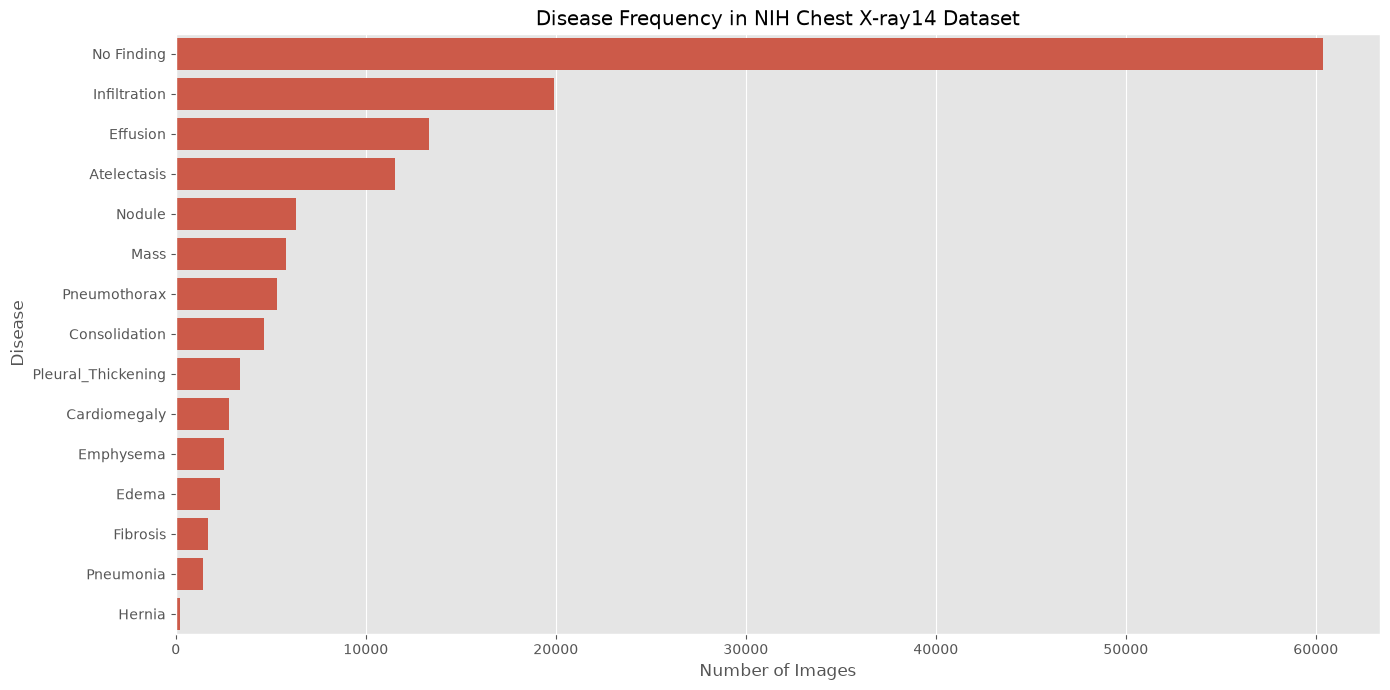

In [25]:
# ==========================================
# Disease Distribution
# ==========================================

plt.figure(figsize=(14,7))

sns.barplot(
    data=disease_df,
    x="Count",
    y="Disease"
)

plt.title("Disease Frequency in NIH Chest X-ray14 Dataset")
plt.xlabel("Number of Images")
plt.ylabel("Disease")

plt.tight_layout()

plt.show()

In [26]:
# ==========================================
# Most Common Label Combinations
# ==========================================

top_labels = (
    df["Finding Labels"]
    .value_counts()
    .head(10)
)

display(top_labels)

Finding Labels
No Finding                  60361
Infiltration                 9547
Atelectasis                  4215
Effusion                     3955
Nodule                       2705
Pneumothorax                 2194
Mass                         2139
Effusion|Infiltration        1603
Atelectasis|Infiltration     1350
Consolidation                1310
Name: count, dtype: int64

In [27]:
# ==========================================
# Number of Diseases per Image
# ==========================================

df["Num_Diseases"] = (
    df["Finding Labels"]
    .apply(lambda x: len(x.split("|")))
)

display(df["Num_Diseases"].value_counts().sort_index())

Num_Diseases
1    91324
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64

2026-07-18 23:32:20,849 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-18 23:32:20,893 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


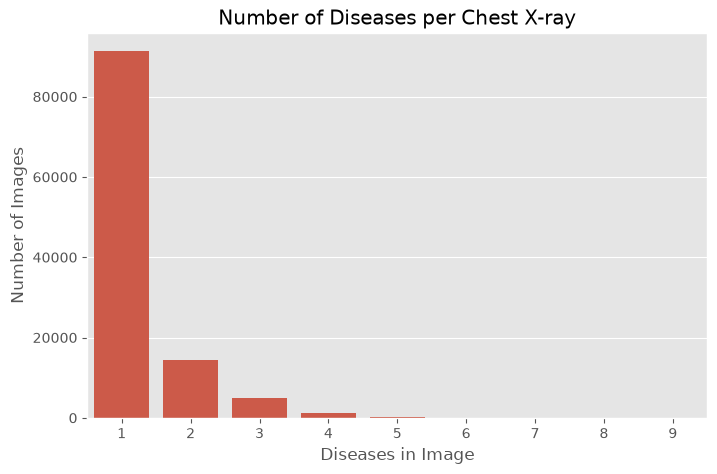

In [28]:
    # ==========================================
# Single vs Multi-label Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Num_Diseases"
)

plt.title("Number of Diseases per Chest X-ray")

plt.xlabel("Diseases in Image")
plt.ylabel("Number of Images")

plt.show()

In [29]:
# ==========================================
# Patient Age Statistics
# ==========================================

print(df["Patient Age"].describe())

count    112120.000000
mean         46.626365
std          16.602680
min           0.000000
25%          34.000000
50%          49.000000
75%          59.000000
max          95.000000
Name: Patient Age, dtype: float64


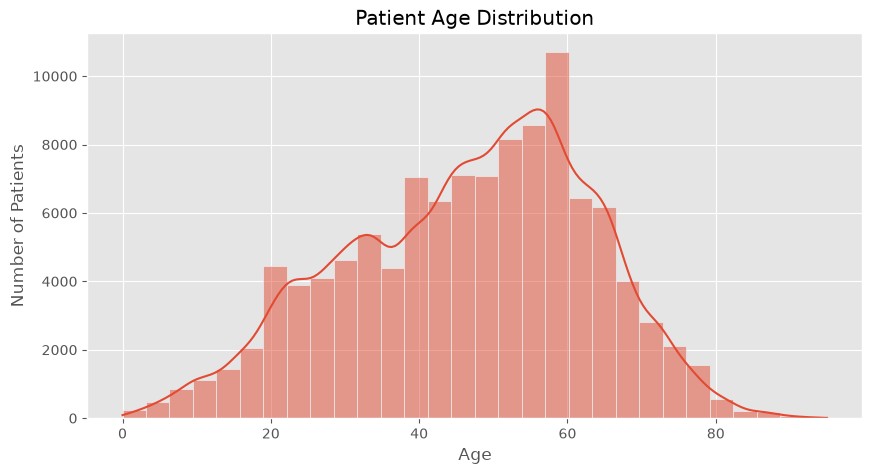

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Patient Age",
    bins=30,
    kde=True
)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

Patient Sex
M    63340
F    48780
Name: count, dtype: int64

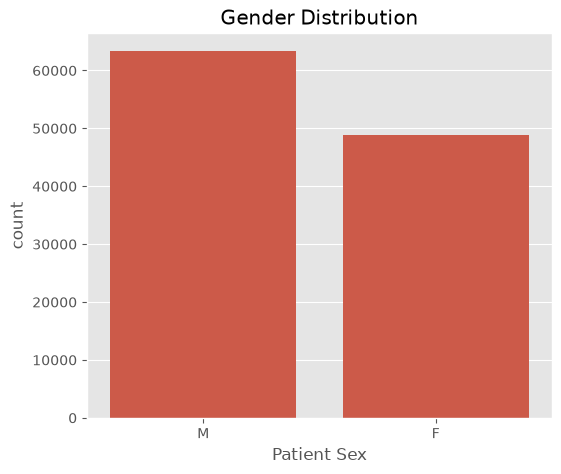

In [32]:
gender_counts = df["Patient Sex"].value_counts()

display(gender_counts)

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Patient Sex"
)

plt.title("Gender Distribution")
plt.show()

View Position
PA    67310
AP    44810
Name: count, dtype: int64

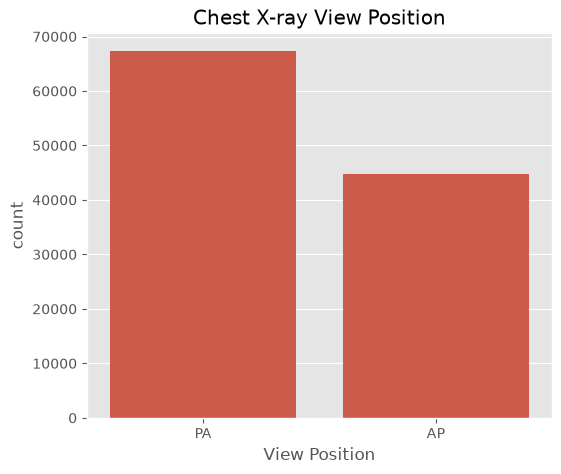

In [33]:
view_counts = df["View Position"].value_counts()

display(view_counts)

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="View Position"
)

plt.title("Chest X-ray View Position")
plt.show()

In [34]:
print(df["Follow-up #"].describe())

count    112120.000000
mean          8.573751
std          15.406320
min           0.000000
25%           0.000000
50%           3.000000
75%          10.000000
max         183.000000
Name: Follow-up #, dtype: float64


In [35]:
print("="*50)

print(f"Total Images      : {len(df):,}")
print(f"Unique Patients   : {df['Patient ID'].nunique():,}")

avg = len(df)/df['Patient ID'].nunique()

print(f"Average Images/Patient : {avg:.2f}")

Total Images      : 112,120
Unique Patients   : 30,805
Average Images/Patient : 3.64


In [36]:
# ==========================================
# Collect All Image Paths
# ==========================================

image_extensions = ["*.png", "*.jpg", "*.jpeg"]

all_images = []

for folder in sorted(IMAGE_DIR.glob("images_*")):
    actual_folder = folder / "images"

    for ext in image_extensions:
        all_images.extend(actual_folder.glob(ext))

print(f"Total Images Found: {len(all_images):,}")

Total Images Found: 112,120


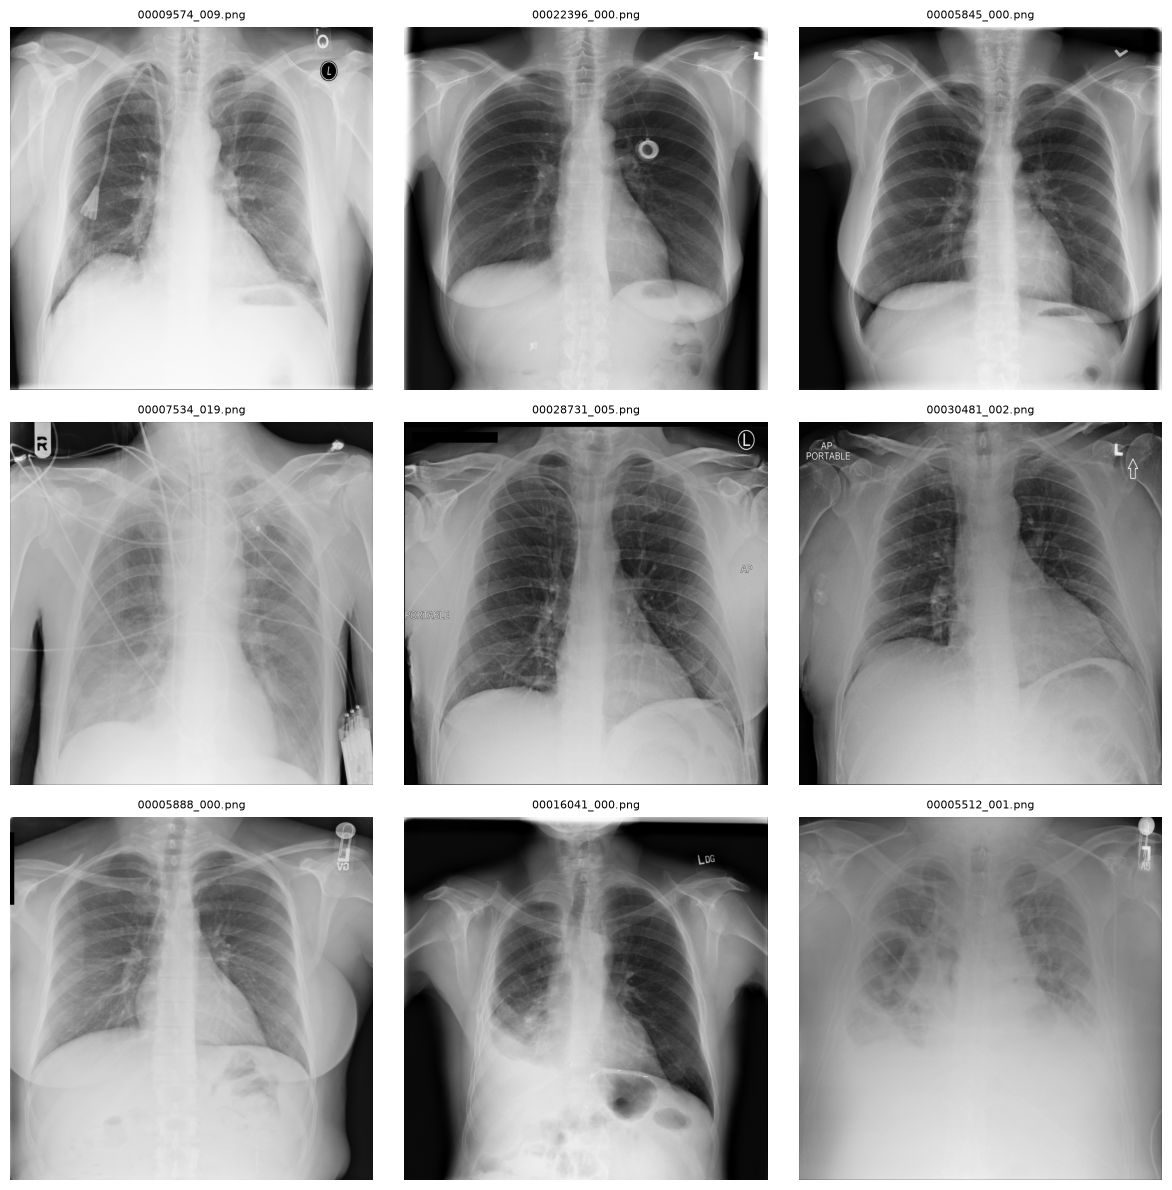

In [37]:
# ==========================================
# Display Random Chest X-rays
# ==========================================

import random

sample_images = random.sample(all_images, 9)

plt.figure(figsize=(12,12))

for i, img_path in enumerate(sample_images):

    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    plt.subplot(3,3,i+1)

    plt.imshow(image, cmap="gray")

    plt.title(img_path.name, fontsize=8)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [38]:
# ==========================================
# Inspect One Image
# ==========================================

sample = sample_images[0]

image = cv2.imread(str(sample), cv2.IMREAD_GRAYSCALE)

print("="*50)

print("Filename :", sample.name)
print("Shape    :", image.shape)
print("Datatype :", image.dtype)
print("Minimum  :", image.min())
print("Maximum  :", image.max())
print("Mean     :", image.mean())

Filename : 00009574_009.png
Shape    : (1024, 1024)
Datatype : uint8
Minimum  : 0
Maximum  : 255
Mean     : 181.97808837890625


In [39]:
# ==========================================
# Check Image Resolution
# ==========================================

resolutions = []

for img_path in random.sample(all_images, 100):

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    resolutions.append(img.shape)

resolution_df = pd.DataFrame(
    resolutions,
    columns=["Height", "Width"]
)

display(resolution_df.value_counts())

Height  Width
1024    1024     100
Name: count, dtype: int64

In [40]:
# ==========================================
# Load Bounding Box Data
# ==========================================

bbox_df = pd.read_csv(BBOX_FILE)

print("Bounding Box Dataset Shape:", bbox_df.shape)

display(bbox_df.head())

Bounding Box Dataset Shape: (984, 9)


,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN


In [41]:
print("=" * 60)
print("BOUNDING BOX DATASET")
print("=" * 60)

bbox_df.info()

BOUNDING BOX DATASET
<class 'pandas.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Image Index    984 non-null    str    
 1   Finding Label  984 non-null    str    
 2   Bbox [x        984 non-null    float64
 3   y              984 non-null    float64
 4   w              984 non-null    float64
 5   h]             984 non-null    float64
 6   Unnamed: 6     0 non-null      float64
 7   Unnamed: 7     0 non-null      float64
 8   Unnamed: 8     0 non-null      float64
dtypes: float64(7), str(2)
memory usage: 69.3 KB


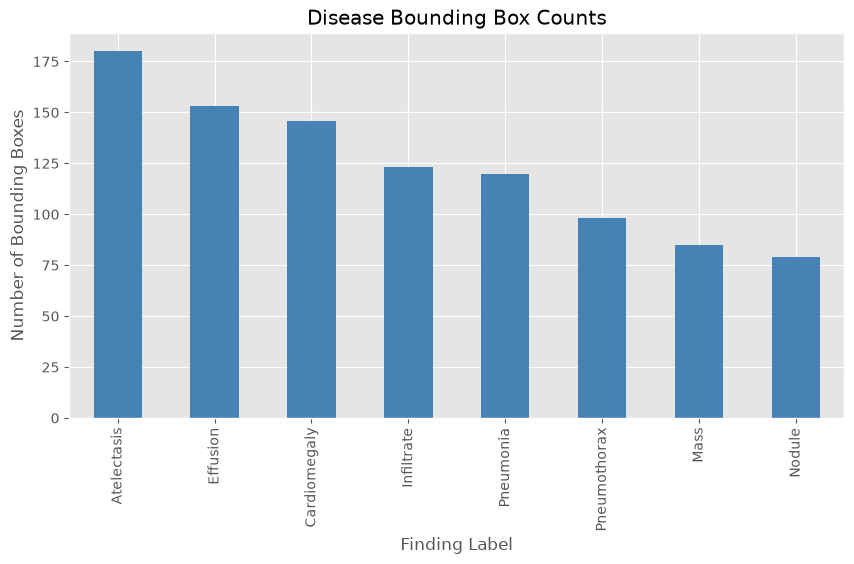

In [42]:
plt.figure(figsize=(10,5))

bbox_df["Finding Label"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Disease Bounding Box Counts")

plt.ylabel("Number of Bounding Boxes")

plt.show()

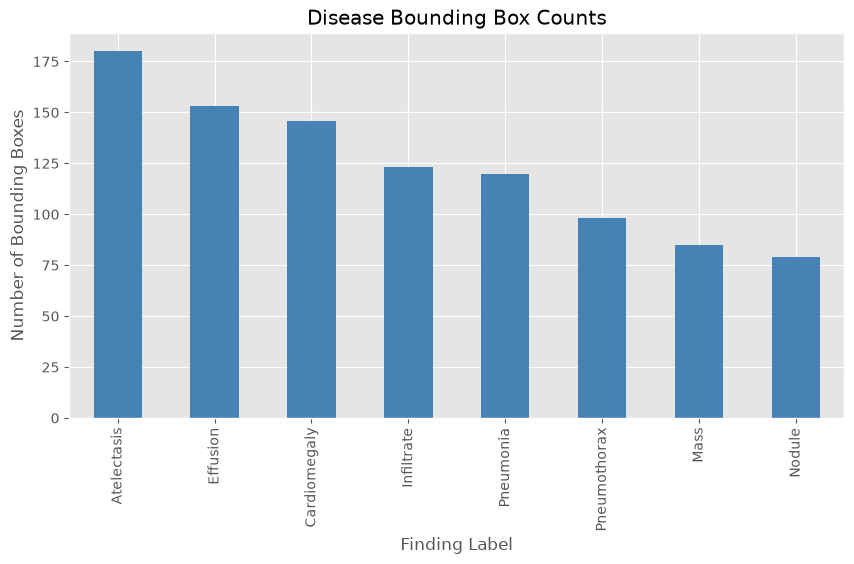

In [43]:
plt.figure(figsize=(10,5))

bbox_df["Finding Label"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Disease Bounding Box Counts")

plt.ylabel("Number of Bounding Boxes")

plt.show()

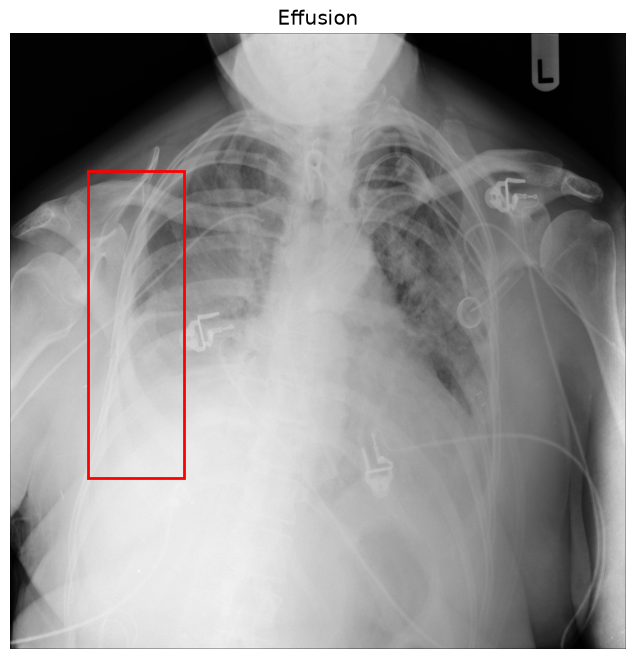

In [50]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample = bbox_df.sample(1).iloc[0]

image_name = sample["Image Index"]

image_path = None

for folder in image_folders:
    candidate = folder / "images" / image_name
    if candidate.exists():
        image_path = candidate
        break

img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(img, cmap="gray")

rect = patches.Rectangle(
    (
        sample["Bbox [x"],   # x-coordinate
        sample["y"]          # y-coordinate
    ),
    sample["w"],             # width
    sample["h]"],            # height
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)

ax.add_patch(rect)

plt.title(sample["Finding Label"])
plt.axis("off")
plt.show()

In [51]:
print("=" * 60)

print("BOUNDING BOX SUMMARY")

print("=" * 60)

print(f"Annotated Images : {bbox_df['Image Index'].nunique()}")

print(f"Total Annotations: {len(bbox_df)}")

print(f"Diseases Covered : {bbox_df['Finding Label'].nunique()}")

BOUNDING BOX SUMMARY
Annotated Images : 880
Total Annotations: 984
Diseases Covered : 8


In [53]:
# ==========================================
# Basic Metadata Cleaning
# ==========================================

clean_df = df.copy()

# Remove duplicate rows
clean_df.drop_duplicates(inplace=True)

# Remove leading/trailing whitespace from column names
clean_df.columns = clean_df.columns.str.strip()

# Remove leading/trailing whitespace from string columns
for col in clean_df.select_dtypes(include="object").columns:
    clean_df[col] = clean_df[col].str.strip()

# Convert age to numeric
clean_df["Patient Age"] = pd.to_numeric(
    clean_df["Patient Age"],
    errors="coerce"
)

# Remove unrealistic ages
clean_df = clean_df[
    (clean_df["Patient Age"] >= 0) &
    (clean_df["Patient Age"] <= 120)
]

print("Cleaned Dataset Shape:", clean_df.shape)

Cleaned Dataset Shape: (112120, 12)


In [54]:
# ==========================================
# Feature Engineering
# ==========================================

# Number of diseases in each image
clean_df["Num_Diseases"] = clean_df["Finding Labels"].apply(
    lambda x: len(x.split("|"))
)

# Binary indicator for normal images
clean_df["Is_Normal"] = clean_df["Finding Labels"].apply(
    lambda x: 1 if x == "No Finding" else 0
)

display(clean_df.head())

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Num_Diseases,Is_Normal
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143,1,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,2,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,2,0
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171,1,1
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168,1,0


In [55]:
# ==========================================
# Save Cleaned Metadata
# ==========================================

processed_dir = DATA_DIR / "processed"
processed_dir.mkdir(exist_ok=True)

output_file = processed_dir / "clean_metadata.csv"

clean_df.to_csv(
    output_file,
    index=False
)

print("✅ Cleaned metadata saved successfully.")
print(f"Location: {output_file}")

✅ Cleaned metadata saved successfully.
Location: c:\Users\HP\MED-AGENT\data\processed\clean_metadata.csv


In [56]:
# ==========================================
# Verify Saved Metadata
# ==========================================

saved_df = pd.read_csv(output_file)

print("Saved Dataset Shape:", saved_df.shape)

display(saved_df.head())

Saved Dataset Shape: (112120, 13)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Num_Diseases,Is_Normal
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143,1,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,2,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,2,0
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171,1,1
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168,1,0
